In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/train_dataset.csv')

In [3]:
df_train = df_train.drop('id', axis=1)

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  24000 non-null  float64
 1   CGPA         24000 non-null  float64
dtypes: float64(2)
memory usage: 375.1 KB


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
X = df_train.drop('CGPA', axis=1)
y = df_train['CGPA']

array([[<Axes: title={'center': 'Study_Hours'}>,
        <Axes: title={'center': 'CGPA'}>]], dtype=object)

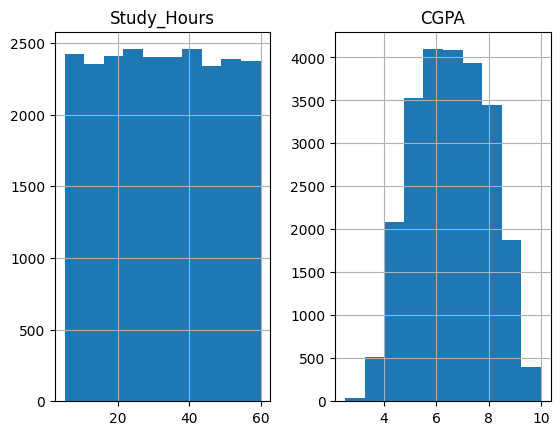

In [7]:
df_train.hist()

<Axes: xlabel='Study_Hours', ylabel='CGPA'>

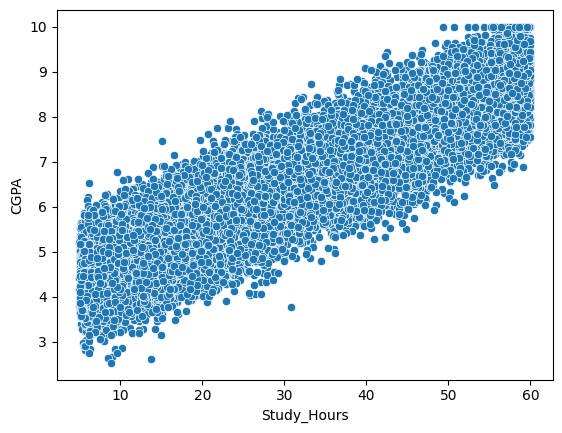

In [8]:
sns.scatterplot(x='Study_Hours', y='CGPA', data=df_train)

In [9]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [10]:
error_list = []
degree_list = []
for i in range(1,5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    poly = PolynomialFeatures(include_bias=False, degree = i)
    X_train = poly.fit_transform(X_train)
    X_test = poly.transform(X_test)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    error_list.append(mse)
    degree_list.append(i)

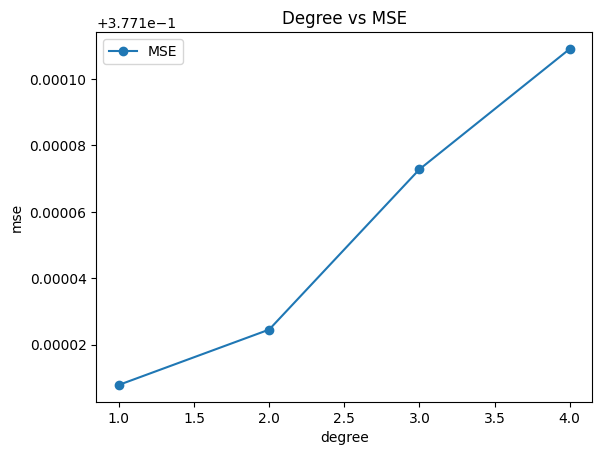

In [11]:
plt.plot(degree_list, error_list, label = 'MSE', marker='o')
plt.xlabel('degree')
plt.ylabel('mse')
plt.title('Degree vs MSE')
plt.legend()

### Choose without polynomial features

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
r2_score(y_test, y_pred)

0.8097614224522988

In [16]:
mse = mean_squared_error(y_test, y_pred)

In [17]:
rmse = np.sqrt(mse)

In [18]:
rmse, y.mean()

(np.float64(0.6140911256085148), np.float64(6.592297083333333))

#### Error percentage

In [19]:
(rmse * 100) / y.mean()

np.float64(9.315282940768277)

In [20]:
import joblib

In [21]:
joblib.dump(model, 'LinearRegression_model.pkl')

['LinearRegression_model.pkl']